# Salary Estimation using K-Nearest Neighbour 

# 1. import necessary library

In [1]:
import pandas as pd
import numpy as np

# 2. import dataset

In [15]:
dataset = pd.read_csv('salary.csv')

In [16]:
dataset

,age,education.num,capital.gain,hours.per.week,income
0,90,9,0,40,<=50K
1,82,9,0,18,<=50K
2,66,10,0,40,<=50K
3,54,4,0,40,<=50K
4,41,10,0,40,<=50K
...,...,...,...,...,...
32556,22,10,0,40,<=50K
32557,27,12,0,38,<=50K
32558,40,9,0,40,>50K
32559,58,9,0,40,<=50K


# 3.Summarize Dataset

In [17]:
dataset.shape

(32561, 5)

In [18]:
dataset.head(5)

,age,education.num,capital.gain,hours.per.week,income
0,90,9,0,40,<=50K
1,82,9,0,18,<=50K
2,66,10,0,40,<=50K
3,54,4,0,40,<=50K
4,41,10,0,40,<=50K


In [6]:
dataset.isnull().sum()

age               0
education.num     0
capital.gain      0
hours.per.week    0
income            0
dtype: int64

In [7]:
dataset.dtypes

age                int64
education.num      int64
capital.gain       int64
hours.per.week     int64
income            object
dtype: object

# 4.Mapping salary Data to binary Value

In [19]:
income_set = set(dataset['income'])
dataset['income'] = dataset['income'].map({'<=50K':0,'>50K':1}).astype(int)
dataset.head

<bound method NDFrame.head of        age  education.num  capital.gain  hours.per.week  income
0       90              9             0              40       0
1       82              9             0              18       0
2       66             10             0              40       0
3       54              4             0              40       0
4       41             10             0              40       0
...    ...            ...           ...             ...     ...
32556   22             10             0              40       0
32557   27             12             0              38       0
32558   40              9             0              40       1
32559   58              9             0              40       0
32560   22              9             0              20       0

[32561 rows x 5 columns]>

In [9]:
income_set

{'<=50K', '>50K'}

# Segregate dataset into X and Y

In [20]:
X = dataset.iloc[:, :-1].values
X

array([[90,  9,  0, 40],
       [82,  9,  0, 18],
       [66, 10,  0, 40],
       ...,
       [40,  9,  0, 40],
       [58,  9,  0, 40],
       [22,  9,  0, 20]], shape=(32561, 4))

In [23]:
Y = dataset.iloc[:, -1].values
Y

array([0, 0, 0, ..., 1, 0, 0], shape=(32561,))

# Splitting dataset into Train and Test

In [35]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,Y,test_size=0.25,random_state=0)

# Feature Scalling
- we scale our data to make all the features contribute equally to the result

In [37]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)
X_train,X_test

(array([[ 1.20264866, -2.76154633, -0.14509813, -0.03923011],
        [ 0.25021666, -0.42608063, -0.14509813, -0.03923011],
        [ 0.25021666, -0.42608063, -0.14509813, -0.03923011],
        ...,
        [-0.92200734, -0.81532491, -0.14509813,  0.85306386],
        [ 0.39674466,  1.52014079, -0.14509813, -0.03923011],
        [ 0.03042466, -0.42608063,  0.83219401, -0.03923011]],
       shape=(24420, 4)),
 array([[ 1.27591266, -1.98305776, -0.14509813, -0.03923011],
        [-1.43485534, -0.42608063, -0.14509813, -1.25599461],
        [-1.14179934, -0.03683634, -0.14509813, -0.44481828],
        ...,
        [ 0.39674466, -0.03683634, -0.14509813,  1.1775344 ],
        [ 1.42244067, -0.42608063, -0.14509813,  0.77194623],
        [ 1.20264866, -0.03683634, -0.14509813,  0.36635806]],
       shape=(8141, 4)))

# finding the Best K-value

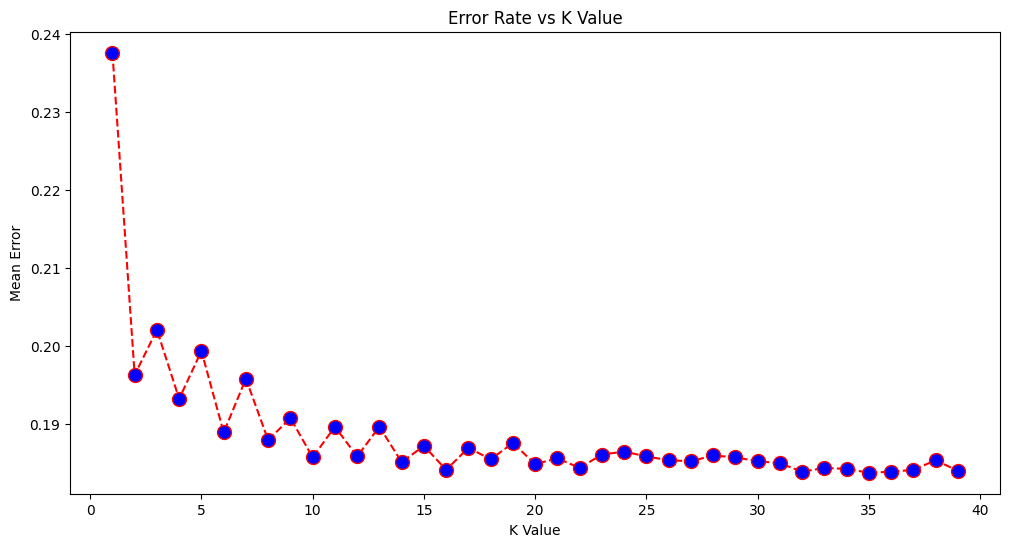

In [38]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

error = []

# Calculating error for K values between 1 and 40
for i in range(1, 40):
    model = KNeighborsClassifier(n_neighbors=i)
    model.fit(X_train, y_train)
    pred_i = model.predict(X_test)
    error.append(np.mean(pred_i != y_test))

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(range(1, 40), error,color='red', linestyle='dashed', marker='o',markerfacecolor='blue',markersize=10)
plt.title('Error Rate vs K Value')
plt.xlabel('K Value')
plt.ylabel('Mean Error')
plt.show()

# Training

In [41]:
from sklearn.neighbors import KNeighborsClassifier
# p = 2 na Eucledian distance formula using
model = KNeighborsClassifier(n_neighbors = 2,metric = 'minkowski',p= 2)
model.fit(X_train,y_train)

,n_neighbors,2
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


#  Predicting whether new Customer with Age and salary will buy or not

In [55]:
age = int(input("Enter New Employee's Age: "))
edu = int(input("Enter New Employee's Education: "))
cg = int(input("Enter New Employee's Captail Gain: "))
wh = int(input("Enter New Employee's Hour's per week: "))

newEmp = [[age,edu,cg,wh]]
res = model.predict(sc.transform(newEmp))
print(res)

if res == 1:
    print("Employee might got Salary above 50K!")
else:
    print("Customer might not got Salary above 50K!")
    

Enter New Employee's Age:  67
Enter New Employee's Education:  40
Enter New Employee's Captail Gain:  0
Enter New Employee's Hour's per week:  45


[0]
Customer might not got Salary above 50K!


# Prediction for all Test data

In [47]:
y_pred = model.predict(X_test)

print(np.concatenate((y_pred.reshape(len(y_pred), 1), 
                      y_test.reshape(len(y_test), 1)), axis=1))

[[0 0]
 [0 0]
 [0 0]
 ...
 [0 0]
 [0 0]
 [0 0]]


# Model Accuracy performance

In [48]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test,y_pred)

print("Confusion Matrix: ")
print(cm)


Confusion Matrix: 
[[5915  278]
 [1320  628]]


In [49]:
print("Accuracy of the Model: {0}%".format(accuracy_score(y_test,y_pred)*100))

Accuracy of the Model: 80.37096179830488%


# THE END!